# GERMLINE ANALYSIS

## Import libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
import seaborn as sns  
import itertools
import pandas as pd
from anarci import anarci
from Bio.Seq import Seq
from riot_na import create_riot_aa, Organism, Scheme, RiotNumberingAA, AirrRearrangementEntryAA

from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm

import os
import glob
current_directory = os.getcwd()
os.chdir(current_directory)


## Load data:

In [19]:
data = pd.read_csv('./Data/Datasets/Boughter_Jain_Shehata_data.csv',index_col=[0])
Shehata_SI = pd.read_excel('./Revision/Shehata_SI.xlsx')

# --- Define class: 
cls_list = []
for i in range(len(data)):
    if data['Dataset'].iloc[i] == 'Jain':
        react_val = data['react'].iloc[i]
        cls = 0 if react_val == 0 else 0.5 if (react_val > 0 and react_val < 4) else 1

    elif data['Dataset'].iloc[i] == 'Boughter':
        react_val = data['react'].iloc[i]
        cls = 0 if react_val == 0 else 0.5 if (react_val > 0 and react_val < 4) else 1
        
    elif data['Dataset'].iloc[i] == 'Shehata':
        react_val = data['PSR Score'].iloc[i]
        cls = 0 if react_val <= 0.33 else 1

    cls_list.append(cls)

data['class'] = cls_list

# --- Define Ab type for other datasets than Boughter:
Ab_type = []
for i in range(len(data)):
    if data['Dataset'].iloc[i] == 'Boughter':
        ab_type = data['Ab type'].iloc[i]
    elif data['Dataset'].iloc[i] == 'Jain':
        ab_type = 'clinical stage'
    elif data['Dataset'].iloc[i] == 'Shehata':
        ab_type = list(Shehata_SI[Shehata_SI['Clone name']==data['Name'].iloc[i]]['B cell subset'])[0]
        
    Ab_type.append(ab_type)
    
data['Ab type'] = Ab_type

data

,Name,Ab type,Dataset,L-CDR1,L-CDR2,L-CDR3,H-CDR1,H-CDR2,H-CDR3,VH,VL,VH_VL_joined,HL-CDRs_joined,H-CDRs_joined,L-CDRs_joined,react,PSR Score,class
0,0,Mouse IgA,Boughter,TDIDDD,EGN,LQSDNMPYTF,GYSITSDY,ISYSGST,ARRGYYYGSFDYW,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,DIQMTQSPASLSVATGEKVTIRCITSTDIDDDMNWYQQKPGEPPKL...,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,GYSITSDYISYSGSTARRGYYYGSFDYWTDIDDDEGNLQSDNMPYTF,GYSITSDYISYSGSTARRGYYYGSFDYW,TDIDDDEGNLQSDNMPYTF,0,NaN,0.0
1,1,Mouse IgA,Boughter,QEISGY,AAS,LQYASYPPTF,GYTFTSYW,IHPSDSDT,AIDYDQAMDYW,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,DIQMNQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,GYTFTSYWIHPSDSDTAIDYDQAMDYWQEISGYAASLQYASYPPTF,GYTFTSYWIHPSDSDTAIDYDQAMDYW,QEISGYAASLQYASYPPTF,0,NaN,0.0
2,2,Mouse IgA,Boughter,QDVGTA,WAS,QQYSSYPFTF,GYSITSGYY,ISYDGS,ARFYGNYEDYYAMDYW,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,ETTVTQSHKFMSTSVGDRVSITCKASQDVGTAVAWYQQKPGQSPKL...,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,GYSITSGYYISYDGSARFYGNYEDYYAMDYWQDVGTAWASQQYSSY...,GYSITSGYYISYDGSARFYGNYEDYYAMDYW,QDVGTAWASQQYSSYPFTF,0,NaN,0.0
3,3,Mouse IgA,Boughter,QDIGSS,AT,LQYASSPWTF,GFTFTDYY,IRNKANGYTT,ARLDSSGYDYAMDYW,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,DIQMNQSPSSLSASLGERVSLTCRASQDIGSSLNWLQQEPDGTIKR...,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYWQDIGSSATLQYAS...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYW,QDIGSSATLQYASSPWTF,0,NaN,0.0
4,4,Mouse IgA,Boughter,QSIGTS,YAS,QQSNSWPLTF,GFTFSSYG,ISSGGSYT,ARQEGNSGEYYFDYW,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,ENVLTQSPAILSVSPGERVSFSCRASQSIGTSIHWYQQRTNGSPRL...,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYWQSIGTSYASQQSNSW...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYW,QSIGTSYASQQSNSWPLTF,0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,ADI-47245,Naïve,Shehata,SGSSSNIGSNTVN,SNNQRPS,AAWDDSLNGLYV,GSFSGYYWS,EINHSGSTNYNPSLKS,ARGYKEYSSSSLTPRGRREAYYFGDY,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,SYELTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPK...,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,GSFSGYYWSEINHSGSTNYNPSLKSARGYKEYSSSSLTPRGRREAY...,GSFSGYYWSEINHSGSTNYNPSLKSARGYKEYSSSSLTPRGRREAY...,SGSSSNIGSNTVNSNNQRPSAAWDDSLNGLYV,0,0.000000,0.0
1519,ADI-45475,Naïve,Shehata,RASQSVSSSYLA,GASSRAT,QQYGSSSYT,GTFSSYAIS,GIIPIFGTANYAQKFQG,AREADDYVWGSYRYPNFDY,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,DIVMTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,GTFSSYAISGIIPIFGTANYAQKFQGAREADDYVWGSYRYPNFDYR...,GTFSSYAISGIIPIFGTANYAQKFQGAREADDYVWGSYRYPNFDY,RASQSVSSSYLAGASSRATQQYGSSSYT,0,0.000000,0.0
1520,ADI-47271,Naïve,Shehata,RASQSISSYLN,AASSLQS,QQSYSTPTWT,GSISSYYWS,YIYYSGSTNYNPSLKS,ARGGYYYDSSGYYFYFDY,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,DIRVTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,GSISSYYWSYIYYSGSTNYNPSLKSARGGYYYDSSGYYFYFDYRAS...,GSISSYYWSYIYYSGSTNYNPSLKSARGGYYYDSSGYYFYFDY,RASQSISSYLNAASSLQSQQSYSTPTWT,0,0.071894,0.0
1521,ADI-47324,Naïve,Shehata,RASQSVSSNLA,GASTRAT,QQYNNWPRT,FTFSGSAMH,RIRSKANSYATAYAASVKG,TTFIEWELLFQH,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,ETTLTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,FTFSGSAMHRIRSKANSYATAYAASVKGTTFIEWELLFQHRASQSV...,FTFSGSAMHRIRSKANSYATAYAASVKGTTFIEWELLFQH,RASQSVSSNLAGASTRATQQYNNWPRT,0,0.124712,0.0


## Germline:

In [20]:
# Create RiotNumberingAA once

results = []
for i, (VH, VL) in enumerate( zip(list(data['VH']), list(data['VL'])) ):
    header = str(i)
    if data['Ab type'].iloc[i]=='Mouse IgA':
        species = 'mouse'
        riot_aa: RiotNumberingAA = create_riot_aa(allowed_species=(Organism.HOMO_SAPIENS,)) #MUS_MUSCULUS
    else:
        species = 'human'
        riot_aa: RiotNumberingAA = create_riot_aa(allowed_species=(Organism.HOMO_SAPIENS,)) 
    
    result_VH = riot_aa.run_on_sequence(header=header,
                                        query_sequence=VH,
                                        scheme=Scheme.IMGT,
                                        extend_alignment=True
                                        )
    result_VL = riot_aa.run_on_sequence(header=header,
                                        query_sequence=VL,
                                        scheme=Scheme.IMGT,
                                        extend_alignment=True
                                        )
    d = {'index': i,
         'Name': header,
         'numbering_scheme': result_VH.numbering_scheme,
         'locus_species VH': result_VH.locus_species,
         'VH_aa': result_VH.sequence_aa,
         'VH_alignment_aa': result_VH.sequence_alignment_aa,
         'VH_germline_alignment_aa': result_VH.germline_alignment_aa,
         'locus VH': result_VH.locus,
         'v_call VH': result_VH.v_call,
         'j_call VH': result_VH.j_call,
         'v_sequence_alignment_aa VH': result_VH.v_sequence_alignment_aa,
         'v_germline_alignment_aa VH': result_VH.v_germline_alignment_aa,
         'j_sequence_alignment_aa VH': result_VH.j_sequence_alignment_aa,
         'j_germline_alignment_aa VH': result_VH.j_germline_alignment_aa,
         'v_identity_aa VH': result_VH.v_identity_aa,
         'j_identity_aa VH': result_VH.j_identity_aa,
         'c_identity_aa VH': result_VH.c_identity_aa,

         'locus_species VL': result_VL.locus_species,
         'VL_aa': result_VL.sequence_aa,
         'VL_alignment_aa': result_VL.sequence_alignment_aa,
         'VL_germline_alignment_aa': result_VL.germline_alignment_aa,
         'locus VL': result_VL.locus,
         'v_call VL': result_VL.v_call,
         'j_call VL': result_VL.j_call,
         'v_sequence_alignment_aa VL': result_VL.v_sequence_alignment_aa,
         'v_germline_alignment_aa VL': result_VL.v_germline_alignment_aa,
         'j_sequence_alignment_aa VL': result_VL.j_sequence_alignment_aa,
         'j_germline_alignment_aa VL': result_VL.j_germline_alignment_aa,
         'v_identity_aa VL': result_VL.v_identity_aa,
         'j_identity_aa VL': result_VL.j_identity_aa,
         'c_identity_aa VL': result_VL.c_identity_aa,
         }

    results.append(d)


df_results = pd.DataFrame(results).set_index('index')
df_results

,Name,numbering_scheme,locus_species VH,VH_aa,VH_alignment_aa,VH_germline_alignment_aa,locus VH,v_call VH,j_call VH,v_sequence_alignment_aa VH,...,locus VL,v_call VL,j_call VL,v_sequence_alignment_aa VL,v_germline_alignment_aa VL,j_sequence_alignment_aa VL,j_germline_alignment_aa VL,v_identity_aa VL,j_identity_aa VL,c_identity_aa VL
index,,,,,,,,,,,,,,,,,,,,,
0,0,imgt,human,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSD--YWNWIRKFPGNK...,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGGYYWSWIRQHPGKG...,igh,IGHV4-31*03,IGHJ6*02,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSD--YWNWIRKFPGNK...,...,igk,IGKV1D-33*01,IGKJ2*01,DIQMTQSPASLSVATGEKVTIRCITSTDIDDDMNWYQQKPGEPPKL...,DIQMTQSPSSLSASVGDRVTITCQASQDISNYLNWYQQKPGKAPKL...,YTFGGGTKLEIK,YTFGQGTKLEIK,0.621053,0.916667,None
1,1,imgt,human,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,QLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLEWI...,QLVQSGAEVKKPGASVKVSCKASGYTFTSYYMHWVRQAPGQGLEWM...,igh,IGHV1-46*01,IGHJ6*02,QLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLEWI...,...,igk,IGKV1-17*03,IGKJ4*01,DIQMNQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,DIQMTQSPSAMSASVGDRVTITCRASQGISNYLAWFQQKPGKVPKR...,TFGGGTKLEIK,TFGGGTKVEIK,0.705263,0.909091,None
2,2,imgt,human,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSG-YYWNWIRQFPGNK...,QVQLQESGPGLVKPSETLSLTCTVSGGSVSSGSYYWSWIRQPPGKG...,igh,IGHV4-61*01,IGHJ6*02,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSG-YYWNWIRQFPGNK...,...,igk,IGKV1D-13*02,IGKJ2*01,VTQSHKFMSTSVGDRVSITCKASQDVGTAVAWYQQKPGQSPKLLIY...,LTQSPSSLSASVGDRVTITCRASQGISSALAWYQQKPGKAPKLLIY...,FTFGSGTKLEIK,YTFGQGTKLEIK,0.673913,0.833333,None
3,3,imgt,human,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSDHYMDWVRQAPGKGLE...,igh,IGHV3-72*01,IGHJ6*02,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,...,igk,IGKV1-NL1*01,IGKJ1*01,DIQMNQSPSSLSASLGERVSLTCRASQDIGSSLNWLQQEPDGTIKR...,DIQMTQSPSSLSASVGDRVTITCRASQGISNSLAWYQQKPGKAPKL...,WTFGGGTKLEIK,WTFGQGTKVEIK,0.673684,0.833333,None
4,4,imgt,human,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,igh,IGHV3-21*01,IGHJ4*02,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,...,igk,IGKV6-21*02,IGKJ4*01,ENVLTQSPAILSVSPGERVSFSCRASQSIGTSIHWYQQRTNGSPRL...,EIVLTQSPDFQSVTPKEKVTITCRASQSIGSSLHWYQQKPDQSPKL...,LTFGAGTKLELK,LTFGGGTKVEIK,0.715789,0.750000,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,1518,imgt,human,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,igh,IGHV4-34*01,IGHJ4*02,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,...,igl,IGLV1-44*01,IGLJ1*01,LTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPKLLI...,LTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPKLLI...,YVFGTGTKLTVL,YVFGTGTKVTVL,1.000000,0.916667,None
1519,1519,imgt,human,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,igh,IGHV1-69*01,IGHJ4*02,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,...,igk,IGKV3-20*01,IGKJ2*01,DIVMTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,YTFGQGTKLEIK,YTFGQGTKLEIK,0.978947,1.000000,None
1520,1520,imgt,human,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,igh,IGHV4-59*01,IGHJ4*02,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,...,igk,IGKV1D-39*01,IGKJ1*01,DIRVTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,WTFGQGTKVDIK,WTFGQGTKVEIK,0.978947,0.916667,None


In [21]:
data_combined = pd.concat([data, df_results], axis=1)
data_combined

,Name,Ab type,Dataset,L-CDR1,L-CDR2,L-CDR3,H-CDR1,H-CDR2,H-CDR3,VH,...,locus VL,v_call VL,j_call VL,v_sequence_alignment_aa VL,v_germline_alignment_aa VL,j_sequence_alignment_aa VL,j_germline_alignment_aa VL,v_identity_aa VL,j_identity_aa VL,c_identity_aa VL
0,0,Mouse IgA,Boughter,TDIDDD,EGN,LQSDNMPYTF,GYSITSDY,ISYSGST,ARRGYYYGSFDYW,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,...,igk,IGKV1D-33*01,IGKJ2*01,DIQMTQSPASLSVATGEKVTIRCITSTDIDDDMNWYQQKPGEPPKL...,DIQMTQSPSSLSASVGDRVTITCQASQDISNYLNWYQQKPGKAPKL...,YTFGGGTKLEIK,YTFGQGTKLEIK,0.621053,0.916667,None
1,1,Mouse IgA,Boughter,QEISGY,AAS,LQYASYPPTF,GYTFTSYW,IHPSDSDT,AIDYDQAMDYW,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,...,igk,IGKV1-17*03,IGKJ4*01,DIQMNQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,DIQMTQSPSAMSASVGDRVTITCRASQGISNYLAWFQQKPGKVPKR...,TFGGGTKLEIK,TFGGGTKVEIK,0.705263,0.909091,None
2,2,Mouse IgA,Boughter,QDVGTA,WAS,QQYSSYPFTF,GYSITSGYY,ISYDGS,ARFYGNYEDYYAMDYW,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,...,igk,IGKV1D-13*02,IGKJ2*01,VTQSHKFMSTSVGDRVSITCKASQDVGTAVAWYQQKPGQSPKLLIY...,LTQSPSSLSASVGDRVTITCRASQGISSALAWYQQKPGKAPKLLIY...,FTFGSGTKLEIK,YTFGQGTKLEIK,0.673913,0.833333,None
3,3,Mouse IgA,Boughter,QDIGSS,AT,LQYASSPWTF,GFTFTDYY,IRNKANGYTT,ARLDSSGYDYAMDYW,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,...,igk,IGKV1-NL1*01,IGKJ1*01,DIQMNQSPSSLSASLGERVSLTCRASQDIGSSLNWLQQEPDGTIKR...,DIQMTQSPSSLSASVGDRVTITCRASQGISNSLAWYQQKPGKAPKL...,WTFGGGTKLEIK,WTFGQGTKVEIK,0.673684,0.833333,None
4,4,Mouse IgA,Boughter,QSIGTS,YAS,QQSNSWPLTF,GFTFSSYG,ISSGGSYT,ARQEGNSGEYYFDYW,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,...,igk,IGKV6-21*02,IGKJ4*01,ENVLTQSPAILSVSPGERVSFSCRASQSIGTSIHWYQQRTNGSPRL...,EIVLTQSPDFQSVTPKEKVTITCRASQSIGSSLHWYQQKPDQSPKL...,LTFGAGTKLELK,LTFGGGTKVEIK,0.715789,0.750000,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,ADI-47245,Naïve,Shehata,SGSSSNIGSNTVN,SNNQRPS,AAWDDSLNGLYV,GSFSGYYWS,EINHSGSTNYNPSLKS,ARGYKEYSSSSLTPRGRREAYYFGDY,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,...,igl,IGLV1-44*01,IGLJ1*01,LTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPKLLI...,LTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPKLLI...,YVFGTGTKLTVL,YVFGTGTKVTVL,1.000000,0.916667,None
1519,ADI-45475,Naïve,Shehata,RASQSVSSSYLA,GASSRAT,QQYGSSSYT,GTFSSYAIS,GIIPIFGTANYAQKFQG,AREADDYVWGSYRYPNFDY,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,...,igk,IGKV3-20*01,IGKJ2*01,DIVMTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,YTFGQGTKLEIK,YTFGQGTKLEIK,0.978947,1.000000,None
1520,ADI-47271,Naïve,Shehata,RASQSISSYLN,AASSLQS,QQSYSTPTWT,GSISSYYWS,YIYYSGSTNYNPSLKS,ARGGYYYDSSGYYFYFDY,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,...,igk,IGKV1D-39*01,IGKJ1*01,DIRVTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,WTFGQGTKVDIK,WTFGQGTKVEIK,0.978947,0.916667,None
1521,ADI-47324,Naïve,Shehata,RASQSVSSNLA,GASTRAT,QQYNNWPRT,FTFSGSAMH,RIRSKANSYATAYAASVKG,TTFIEWELLFQH,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,...,igk,IGKV3-15*01,IGKJ1*01,ETTLTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,EIVMTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,TFGQGTKVEIK,TFGQGTKVEIK,0.968421,1.000000,None


In [22]:
data_combined.to_csv('./Revision/Germline_results_human_species.csv', index=True)

## Calculate number of mutations from germline:

In [23]:
def find_mutations(germline, seq, ignore_gaps=True, one_based=True):
    """
    Compare aligned sequences and return (count, mutations_list, gap_count).
    Each mutation is formatted as "<germ_res><pos><seq_res>", e.g. "E5A"
    where germline has E, sequence has A at position 5.

    Args:
        germline (str): Germline sequence (aligned).
        seq (str): Query sequence (e.g., antibody sequence).
        ignore_gaps (bool): If True, do not count positions where either char is '-'.
        one_based (bool): If True, positions are 1-based; otherwise 0-based.

    Returns:
        (int, list[str], int): mutation count, list of mutation strings, and gap count.
    """
    if len(seq) != len(germline):
        raise ValueError("Sequences must be same length (aligned).")

    muts = []
    gap_count = 0
    for idx, (g, s) in enumerate(zip(germline, seq)):
        is_gap = (g == '-' or s == '-')
        if is_gap:
            gap_count += 1
            if ignore_gaps:
                continue
        if g != s:
            pos = idx + 1 if one_based else idx
            # format mutation; this will show '-' if a gap is present
            muts.append(f"{g}{pos}{s}")
    return len(muts), muts, gap_count

# Prepare lists
VH_count, VL_count = [], []
VH_mut, VL_mut = [], []
VH_gaps, VL_gaps = [], []

for i in range(len(data_combined)):
    #seq_VH = data_combined['VH_alignment_aa'].iloc[i].upper()
    #germ_VH = data_combined['VH_germline_alignment_aa'].iloc[i].upper()
    #seq_VL = data_combined['VL_alignment_aa'].iloc[i].upper()
    #germ_VL = data_combined['VL_germline_alignment_aa'].iloc[i].upper()

    v_seq_VH = data_combined['v_sequence_alignment_aa VH'].iloc[i].upper()
    v_germ_VH = data_combined['v_germline_alignment_aa VH'].iloc[i].upper()
    v_seq_VL = data_combined['v_sequence_alignment_aa VL'].iloc[i].upper()
    v_germ_VL = data_combined['v_germline_alignment_aa VL'].iloc[i].upper()
    
    v_count_VH, v_muts_VH, v_gaps_VH = find_mutations(v_germ_VH, v_seq_VH, ignore_gaps=True, one_based=True)
    v_count_VL, v_muts_VL, v_gaps_VL = find_mutations(v_germ_VL, v_seq_VL, ignore_gaps=True, one_based=True)

    VH_count.append(v_count_VH)
    VL_count.append(v_count_VL)
    VH_mut.append(v_muts_VH)
    VL_mut.append(v_muts_VL)
    VH_gaps.append(v_gaps_VH)
    VL_gaps.append(v_gaps_VL)

# Add to DataFrame:
data_combined['Number of germline mutations in VH'] = VH_count
data_combined['Number of germline mutations in VL'] = VL_count
data_combined['Mutations in VH (germline-pos-seq)'] = VH_mut
data_combined['Mutations in VL (germline-pos-seq)'] = VL_mut
data_combined['Number of gaps in VH alignment'] = VH_gaps
data_combined['Number of gaps in VL alignment'] = VL_gaps

#data_combined.iloc[0]

In [24]:
# Example to compare with germline similarity from IgBlast:
(len(data_combined['v_sequence_alignment_aa VH'].iloc[0]) - (27+2)) / len(data_combined['v_sequence_alignment_aa VH'].iloc[0])

0.7070707070707071

## (i) Germline sequence identity:

In [91]:
# Define data:
df = data_combined
dataset_col = 'Dataset'
family_col = 'Ab type'
vh_mut_col = 'Number of germline mutations in VH'
vl_mut_col = 'Number of germline mutations in VL'
specificity_col = 'class'

# Output filenames:
summary_csv = "mutation_summary_by_family.csv"
pairwise_csv = "pairwise_family_tests.csv"

# Basic data selection and cleaning:
cols_needed = [dataset_col, family_col, vh_mut_col, vl_mut_col, specificity_col]
missing_cols = [c for c in cols_needed if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing expected columns in DataFrame: {missing_cols}")

df2 = df[cols_needed].copy()
df2 = df2.dropna(subset=[family_col, vh_mut_col, vl_mut_col])

# Ensure numeric mutation counts and specificity class:
df2[vh_mut_col] = pd.to_numeric(df2[vh_mut_col], errors='coerce')
df2[vl_mut_col] = pd.to_numeric(df2[vl_mut_col], errors='coerce')
df2 = df2.dropna(subset=[vh_mut_col, vl_mut_col])


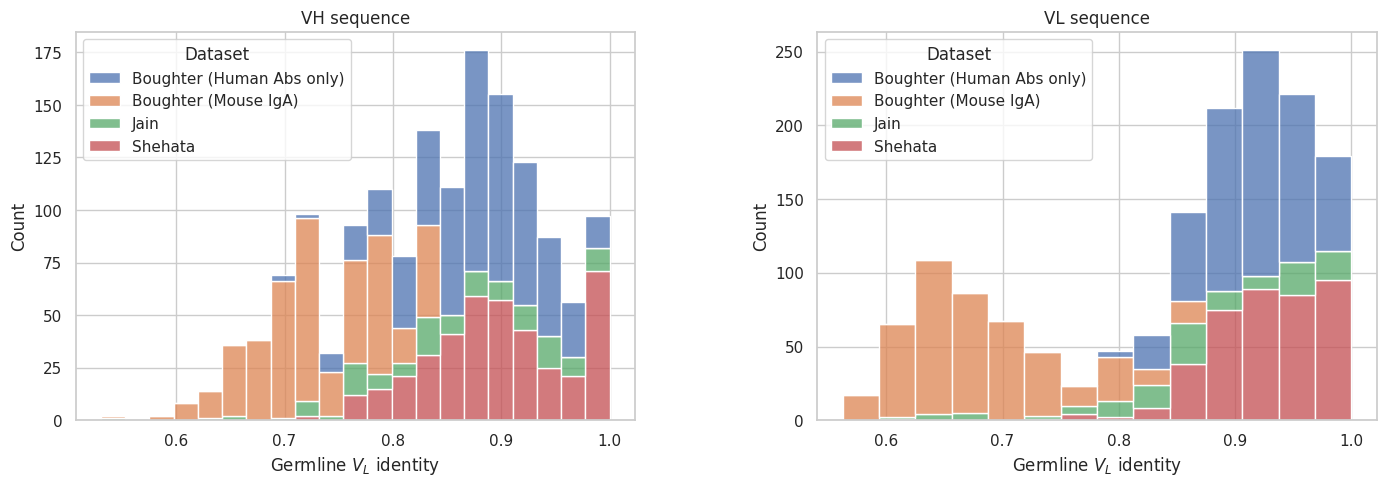

In [92]:
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
data_plot = data_combined.copy()
data_plot['Dataset'] = ['Boughter (Mouse IgA)' if 'Mouse IgA'==data_plot['Ab type'].iloc[i] else 'Boughter (Human Abs only)' if ('Mouse IgA'!=data_plot['Ab type'].iloc[i]) & (d=='Boughter') else d for i, d in enumerate(list(data_plot['Dataset']))]
ax1 = sns.histplot(data=data_plot, #[data_combined['Ab type']!='Mouse IgA'],
                   x='v_identity_aa VH',
                   hue='Dataset',
                   hue_order=['Boughter (Human Abs only)', 'Boughter (Mouse IgA)', 'Jain', 'Shehata'],
                   multiple='stack',
                   )
plt.xlabel('Germline $V_L$ identity')
plt.title('VH sequence')
sns.move_legend(ax1, loc='upper left')

plt.subplot(1,2,2)
ax2=sns.histplot(data=data_plot, #data_combined[data_combined['Ab type']!='Mouse IgA'],
                 x='v_identity_aa VL',
                 hue='Dataset',
                 hue_order=['Boughter (Human Abs only)', 'Boughter (Mouse IgA)', 'Jain', 'Shehata'],
                 multiple='stack',
                 )
plt.xlabel('Germline $V_L$ identity')
plt.title('VL sequence')
sns.move_legend(ax2, loc='upper left')

plt.tight_layout(pad=7)
plt.savefig("./Revision/Figures/Germline_identity_by_datasets.png", dpi=300, bbox_inches='tight')
plt.show()


## (ii) Mutation rate analysis by family

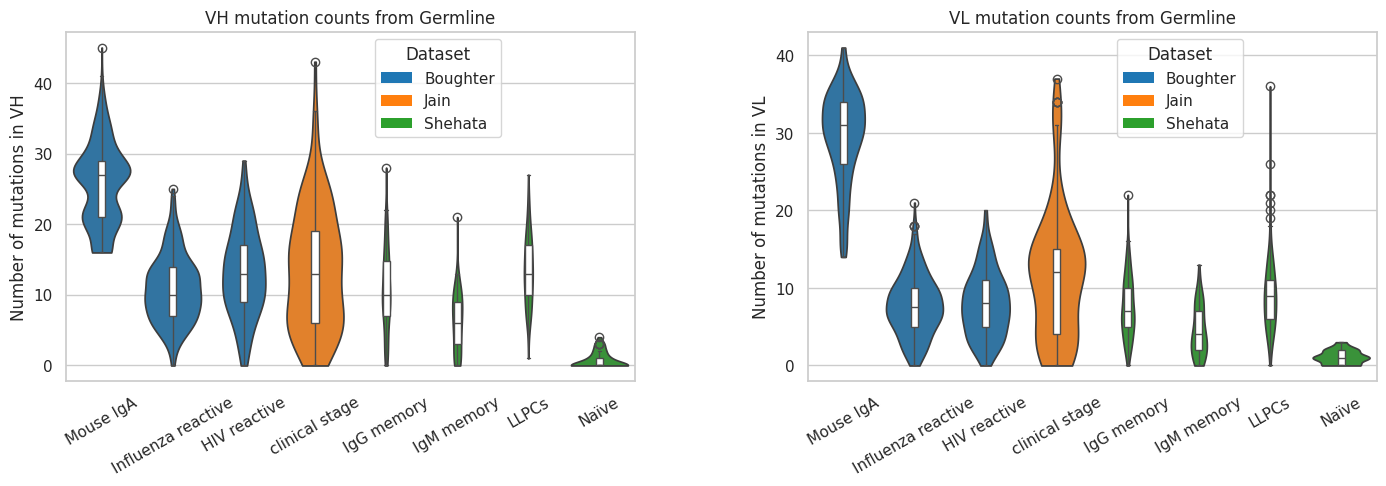

In [93]:
# --- (ii) Mutation rate analysis: by family
summary = df2.groupby(family_col)[[vh_mut_col, vl_mut_col]].agg(['count', 'mean', 'median', 'std'])
#print("Summary mutation stats by family:\n", summary)

# Plot violin and boxplots for VH and VL:
sns.set(style="whitegrid")
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
palette = sns.color_palette("tab10", n_colors=3)
datasets = df2['Dataset'].unique()
ax1=sns.violinplot(data=df2, 
                   x=family_col, 
                   y=vh_mut_col, 
                   hue='Dataset',
                   palette=palette,
                   inner=None, 
                   cut=0,
                   )
sns.boxplot(data=df2, 
            x=family_col, 
            y=vh_mut_col, 
            width=0.1, 
            showcaps=True,
            boxprops={'zorder':2,'facecolor':'white'},
            )
plt.xlabel('')
plt.ylabel('Number of mutations in VH')
plt.title('VH mutation counts from Germline')
plt.xticks(rotation=30)
handles = [Patch(facecolor=palette[i], edgecolor='none', label=datasets[i]) for i in range(len(datasets))]
ax1.legend(handles, datasets, title='Dataset', loc='upper left', bbox_to_anchor=(0.53, 1), frameon=True)

plt.subplot(1,2,2)
ax2=sns.violinplot(data=df2, 
                   x=family_col, 
                   y=vl_mut_col,
                   hue='Dataset',
                   palette=palette,
                   inner=None, 
                   cut=0,
               )
sns.boxplot(data=df2,
            x=family_col, 
            y=vl_mut_col, 
            width=0.1, 
            showcaps=True,
            boxprops={'zorder':2,'facecolor':'white'},
            )
plt.xlabel('')
plt.ylabel('Number of mutations in VL')
plt.title('VL mutation counts from Germline')
plt.xticks(rotation=30)
handles = [Patch(facecolor=palette[i], edgecolor='none', label=datasets[i]) for i in range(len(datasets))]
ax2.legend(handles, datasets, title='Dataset', loc='upper left', bbox_to_anchor=(0.53, 1), frameon=True)

plt.tight_layout(pad=7)
plt.savefig("./Revision/Figures/Mutation_counts_by_family.png", dpi=300, bbox_inches='tight')
plt.show()



## (iii) VH vs. VL mutation bias

/tmp/ipykernel_109946/2341958234.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_yticklabels([label_map[l] for l in class_order])
/tmp/ipykernel_109946/2341958234.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box_right.set_xticklabels([label_map[l] for l in class_order], rotation=45, ha='right'

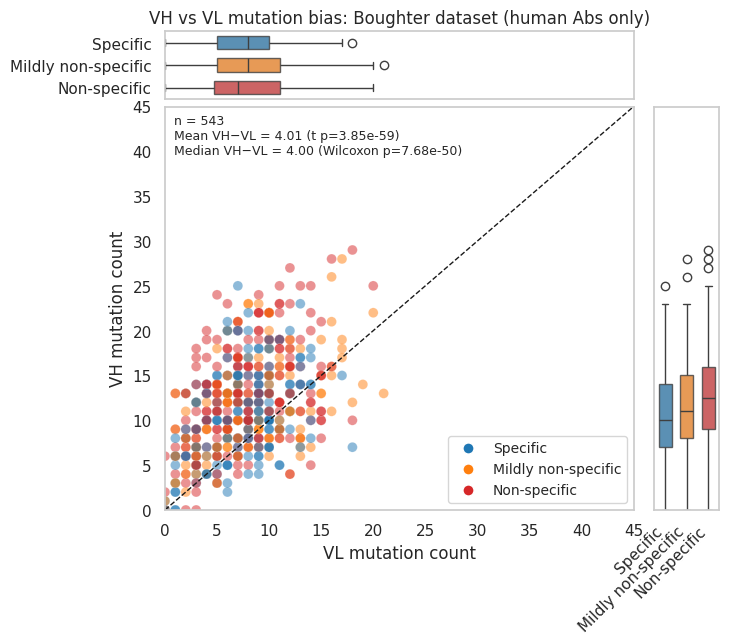

/tmp/ipykernel_109946/2341958234.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_yticklabels([label_map[l] for l in class_order])
/tmp/ipykernel_109946/2341958234.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box_right.set_xticklabels([label_map[l] for l in class_order], rotation=45, ha='right'

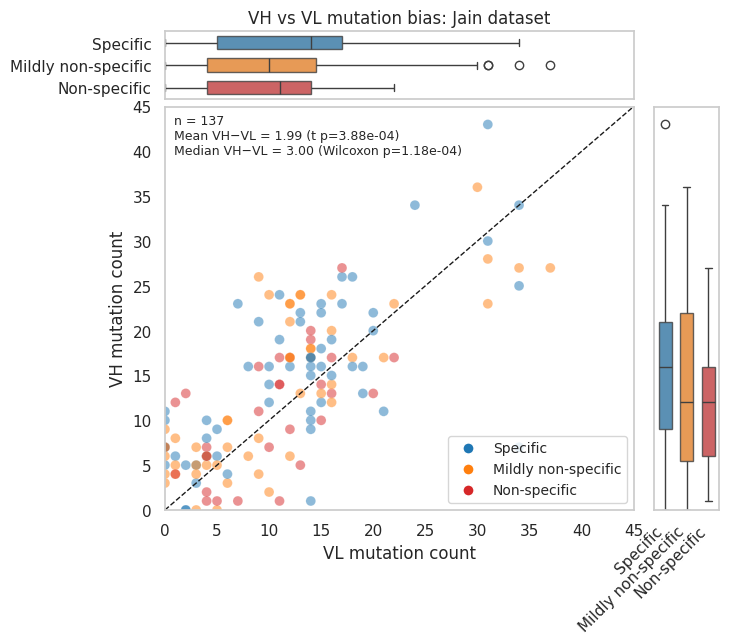

/tmp/ipykernel_109946/2341958234.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_yticklabels([label_map[l] for l in class_order])
/tmp/ipykernel_109946/2341958234.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset,
/tmp/ipykernel_109946/2341958234.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box_right.set_xticklabels([label_map[l] for l in class_order], rotation=45, ha='right'

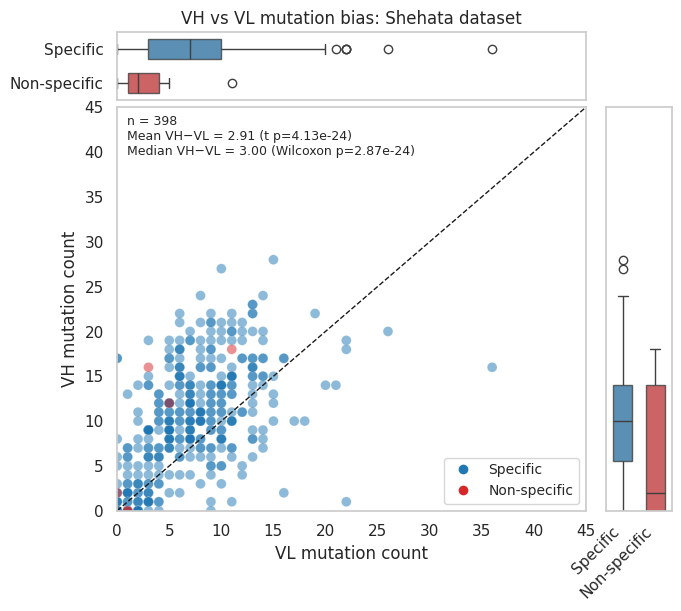

In [94]:
# Figure size:
marginal_in = 0.8       # Thickness in inches for both top and right marginals
scatter_h_in = 4.5      # Height in inches
scatter_w_in = 5.5      # Width in inches
spacer_in = 0.2

fig_w = scatter_w_in + marginal_in
fig_h = marginal_in + scatter_h_in + spacer_in

# Global axis limits:
mn = min(df2[[vl_mut_col, vh_mut_col]].min().min(), 0)
mx = max(df2[[vl_mut_col, vh_mut_col]].max().max(), 1)

for dataset in ['Boughter', 'Jain', 'Shehata']:
    
    # Select only human Abs and compute mutation counts VH-VL:
    df_dataset = df2[df2[family_col] != 'Mouse IgA']
    df_dataset = df_dataset[df_dataset['Dataset'] == dataset].copy()
    df_dataset = df_dataset.dropna(subset=[vh_mut_col, vl_mut_col])
    df_dataset['vh_minus_vl'] = df_dataset[vh_mut_col] - df_dataset[vl_mut_col]
    n = len(df_dataset)
    mean_diff = df_dataset['vh_minus_vl'].mean() if n > 0 else np.nan
    median_diff = df_dataset['vh_minus_vl'].median() if n > 0 else np.nan

    # Paired t-tests:
    t_stat, t_p = stats.ttest_rel(df_dataset[vh_mut_col], df_dataset[vl_mut_col], nan_policy='omit')
    diffs = (df_dataset[vh_mut_col] - df_dataset[vl_mut_col]).dropna()

    # Wilcoxon signed-rank test:
    if len(diffs) > 0 and (diffs != 0).any():
        wil_stat, wil_p = stats.wilcoxon(df_dataset[vh_mut_col], df_dataset[vl_mut_col])
    else:
        wil_stat, wil_p = (np.nan, np.nan)

    # Plot with GridSpec:
    fig = plt.figure(figsize=(fig_w, fig_h))
    height_ratios = [marginal_in, scatter_h_in, spacer_in]
    width_ratios = [scatter_w_in / 2.0, scatter_w_in / 2.0, marginal_in]

    gs = gridspec.GridSpec(3, 3, height_ratios=height_ratios, width_ratios=width_ratios, hspace=0.05, wspace=0.12, top=0.95, bottom=0.08, left=0.07, right=0.95)

    ax_top = fig.add_subplot(gs[0, 0:2])      # Top marginal boxplots for VL
    ax_scatter = fig.add_subplot(gs[1:, 0:2]) # Main scatter (spans rows 1-2, cols 0-1)
    ax_box_right = fig.add_subplot(gs[1:, 2]) # Right marginal boxplots for VH (spans rows 1-2)

    ax_top.grid(False); ax_scatter.grid(False); ax_box_right.grid(False)

    # Define colours:
    class_palette = {0.0: 'tab:blue', 0.5: 'tab:orange', 1.0: 'tab:red'}
    if dataset == 'Shehata':
        label_map = {0.0:'Specific', 1.0:'Non-specific'}
        class_order = [0.0, 1.0]
        palette_list = [class_palette[c] for c in class_order]
    else:
        label_map = {0.0:'Specific', 0.5:'Mildly non-specific', 1.0:'Non-specific'}
        class_order = [0.0, 0.5, 1.0]
        palette_list = [class_palette[c] for c in class_order]
        
    # Main scatter plot:
    sns.scatterplot(data=df_dataset, 
                    x=vl_mut_col,
                    y=vh_mut_col,
                    hue=specificity_col,
                    palette=class_palette,
                    hue_order=class_order,
                    alpha=0.5,
                    s=50,
                    edgecolor='w',
                    linewidth=0.2,
                    ax=ax_scatter,
                    legend=False)
    
    ax_scatter.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    ax_scatter.set_xlim(mn, mx)
    ax_scatter.set_ylim(mn, mx)
    ax_scatter.set_xlabel('VL mutation count')
    ax_scatter.set_ylabel('VH mutation count')

    legend_elems = [Line2D([0], [0], marker='o', color='w', markerfacecolor=class_palette[c], markersize=8, markeredgecolor='w') for c in class_order]
    ax_scatter.legend(legend_elems, [label_map[c] for c in class_order], loc='lower right', fontsize='small')

    # Top boxplot:
    sns.boxplot(data=df_dataset, 
                x=vl_mut_col, 
                y=specificity_col, 
                order=class_order,
                palette=palette_list, 
                orient='h', 
                ax=ax_top, 
                width=0.6, 
                showcaps=True,
                boxprops=dict(alpha=0.8))

    ax_top.set_xlim(ax_scatter.get_xlim())
    ax_top.set_xlabel('')
    ax_top.set_ylabel('')
    if dataset == 'Boughter':
        ax_top.set_title(f'VH vs VL mutation bias: {dataset} dataset (human Abs only)')
    else:
        ax_top.set_title(f'VH vs VL mutation bias: {dataset} dataset')
    ax_top.xaxis.set_visible(False)
    ax_top.set_yticklabels([label_map[l] for l in class_order])

    # Right boxplot:
    sns.boxplot(data=df_dataset, 
                x=specificity_col, 
                y=vh_mut_col, 
                order=class_order,
                palette=palette_list, 
                ax=ax_box_right, 
                width=0.6, 
                showcaps=True, 
                boxprops=dict(alpha=0.8))
    
    ax_box_right.set_ylim(ax_scatter.get_ylim())
    ax_box_right.set_xlabel('')
    ax_box_right.set_ylabel('')
    ax_box_right.yaxis.set_visible(False)
    ax_box_right.set_xticklabels([label_map[l] for l in class_order], rotation=45, ha='right')

    # Text in scatter plot:
    text_lines = [f"n = {n}",
                  f"Mean VH−VL = {mean_diff:.2f} (t p={t_p:.2e})",
                  f"Median VH−VL = {median_diff:.2f} (Wilcoxon p={wil_p:.2e})"]
    text = "\n".join(text_lines)
    box_props = dict(boxstyle='round', facecolor='white', alpha=0)
    ax_scatter.text(0.02, 0.98, text, transform=ax_scatter.transAxes, fontsize=9, verticalalignment='top', bbox=box_props)

    plt.tight_layout()
    plt.savefig(f"./Revision/Figures/VH_VL_mutation_bias_{dataset}.png", dpi=300, bbox_inches='tight')
    plt.show()

## (iv) Germline gene usage:

/tmp/ipykernel_109946/1906849994.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=counts_top,


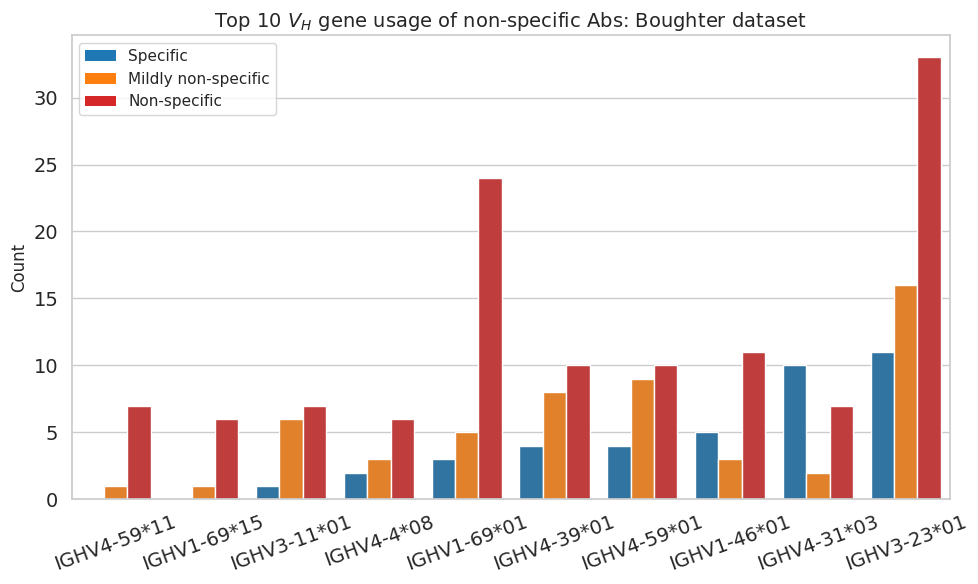

In [95]:
def plot_top_vcalls_by_class_selected_by_class1(df, vcol='v_call VH', title='', classcol='class',
                                                top_n=10, figsize=(10,6),
                                                rotate_x=20):
    """
    Select top_n v_calls by their counts in class==1, order those by class==0 counts (asc),
    and plot grouped barplot colored by class.
    Returns the counts DataFrame used for plotting.
    """
    df = df.copy()

    # compute counts per v_call and class
    counts = df.groupby([vcol, classcol]).size().reset_index(name='Count')

    # compute class==1 counts and get top_n by descending class1_count
    class1_counts = counts[counts[classcol] == 1].groupby(vcol)['Count'].sum().reset_index(name='class1_count')
    top_by_class1 = class1_counts.sort_values('class1_count', ascending=False).head(top_n)[vcol].tolist()

    # if fewer than top_n present, fill from total counts to reach top_n
    if len(top_by_class1) < top_n:
        total_counts = df.groupby(vcol).size().reset_index(name='Total').sort_values('Total', ascending=False)
        for v in total_counts[vcol].tolist():
            if v not in top_by_class1:
                top_by_class1.append(v)
            if len(top_by_class1) >= top_n:
                break
        top_by_class1 = top_by_class1[:top_n]

    # filter counts to only those top v_calls
    counts_top = counts[counts[vcol].isin(top_by_class1)].copy()

    # compute class==0 counts for ordering among selected v_calls
    class0 = counts_top[counts_top[classcol] == 0].groupby(vcol)['Count'].sum().reset_index(name='class0_count')
    # ensure all selected v_calls are present, fill missing with 0
    sel_df = pd.DataFrame({vcol: top_by_class1})
    class0 = sel_df.merge(class0, on=vcol, how='left').fillna(0)

    # order by class0_count ascending (low -> high)
    ordered_vcalls = class0.sort_values('class0_count', ascending=True)[vcol].tolist()

    # set categorical order
    counts_top[vcol] = pd.Categorical(counts_top[vcol], categories=ordered_vcalls, ordered=True)
    
    # Plot
    class_palette = {0.0: 'tab:blue', 0.5: 'tab:orange', 1.0: 'tab:red'}
    label_map = {0.0: 'Specific', 0.5: 'Mildly non-specific', 1.0: 'Non-specific'}
    class_order = sorted(counts_top[classcol].unique())
    palette_list = [class_palette[c] for c in class_order]
    sns.set(style='whitegrid')
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=counts_top, 
                     x=vcol, 
                     y='Count', 
                     hue=classcol, 
                     palette=palette_list,
                     ci=None, 
                     dodge=True)
    ax.set_xlabel(None)#(vcol)
    ax.set_ylabel('Count')
    ax.set_title(f'Top {top_n} $V_H$ gene usage of non-specific Abs: {title}',fontsize=14) #(ordered by class==0 low->high)
    plt.xticks(rotation=rotate_x,fontsize=14)
    plt.yticks(fontsize=14)
    handles = [Patch(facecolor=palette_list[i], edgecolor='none', label=datasets[i]) for i in range(len(class_order))]
    ax.legend(handles, [label_map[c] for c in class_order], loc='upper left', frameon=True)
    plt.tight_layout()
    plt.savefig('./Revision/Figures/Top10_VH_gene_usage_non-specific_Abs_'+ title.split(' ')[0]+ '.png', dpi=300, bbox_inches='tight')
    plt.show()

    return counts_top

def plot_top_vcalls_by_class_selected_by_class0(df, vcol='v_call VH', title='', classcol='class',
                                                top_n=10, figsize=(10,6), palette='deep',
                                                rotate_x=20):
    """
    Select top_n v_calls by their counts in class==0 (highest class-0 counts),
    order those selected v_calls by their class==0 counts ascending (low->high),
    and plot grouped barplot colored by class.
    Returns the counts DataFrame used for plotting.
    """
    df = df.copy()

    # compute counts per v_call and class
    counts = df.groupby([vcol, classcol]).size().reset_index(name='Count')

    # compute class==0 counts and get top_n by descending class0_count
    class0_counts = counts[counts[classcol] == 0].groupby(vcol)['Count'].sum().reset_index(name='class0_count')
    top_by_class0 = class0_counts.sort_values('class0_count', ascending=False).head(top_n)[vcol].tolist()

    # if fewer than top_n present, fill from total counts to reach top_n
    if len(top_by_class0) < top_n:
        total_counts = df.groupby(vcol).size().reset_index(name='Total').sort_values('Total', ascending=False)
        for v in total_counts[vcol].tolist():
            if v not in top_by_class0:
                top_by_class0.append(v)
            if len(top_by_class0) >= top_n:
                break
        top_by_class0 = top_by_class0[:top_n]

    # filter counts to only those top v_calls
    counts_top = counts[counts[vcol].isin(top_by_class0)].copy()

    # compute class==0 counts among selected for ordering
    class0_sel = counts_top[counts_top[classcol] == 0].groupby(vcol)['Count'].sum().reset_index(name='class0_count')
    # ensure all selected v_calls present, fill missing with 0
    sel_df = pd.DataFrame({vcol: top_by_class0})
    class0_sel = sel_df.merge(class0_sel, on=vcol, how='left').fillna(0)

    # order by class0_count ascending (low -> high)
    ordered_vcalls = class0_sel.sort_values('class0_count', ascending=True)[vcol].tolist()

    # set categorical order
    counts_top[vcol] = pd.Categorical(counts_top[vcol], categories=ordered_vcalls, ordered=True)

    # Plot
    class_palette = {0.0: 'tab:blue', 0.5: 'tab:orange', 1.0: 'tab:red'}
    label_map = {0.0: 'Specific', 0.5: 'Mildly non-specific', 1.0: 'Non-specific'}
    class_order = sorted(counts_top[classcol].unique())
    palette_list = [class_palette[c] for c in class_order]
    sns.set(style='whitegrid')
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=counts_top, 
                     x=vcol, 
                     y='Count', 
                     hue=classcol, 
                     palette=palette_list, 
                     ci=None, 
                     dodge=True)
    ax.set_xlabel(vcol)
    ax.set_ylabel('Count')
    ax.set_title(f'Top {top_n} $V_H$ gene usage of specific Abs: {title}') #(ordered by class==0 low->high)
    plt.xticks(rotation=rotate_x)
    handles = [Patch(facecolor=palette_list[i], edgecolor='none', label=datasets[i]) for i in range(len(class_order))]
    ax.legend(handles, [label_map[c] for c in class_order], loc='upper left', frameon=True)
    plt.tight_layout()
    plt.savefig('./Revision/Figures/Top10_VH_gene_usage_specific_Abs_'+ title.split(' ')[0]+ '.png', dpi=300, bbox_inches='tight')
    plt.show()

    return counts_top


Boughter_data = data_combined[data_combined['Dataset']=='Boughter'].copy()
Boughter_data['class'] = [0 if i == 0 else 0.5 if (i > 0 and i < 4) else 1 for i in Boughter_data.react.values]

counts_df = plot_top_vcalls_by_class_selected_by_class1(Boughter_data[Boughter_data['Ab type']!='Mouse IgA'], vcol='v_call VH', title='Boughter dataset', classcol='class', top_n=10)
#counts_df = plot_top_vcalls_by_class_selected_by_class0(Boughter_data, vcol='v_call VH', classcol='class', top_n=10)

/tmp/ipykernel_109946/1906849994.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=counts_top,


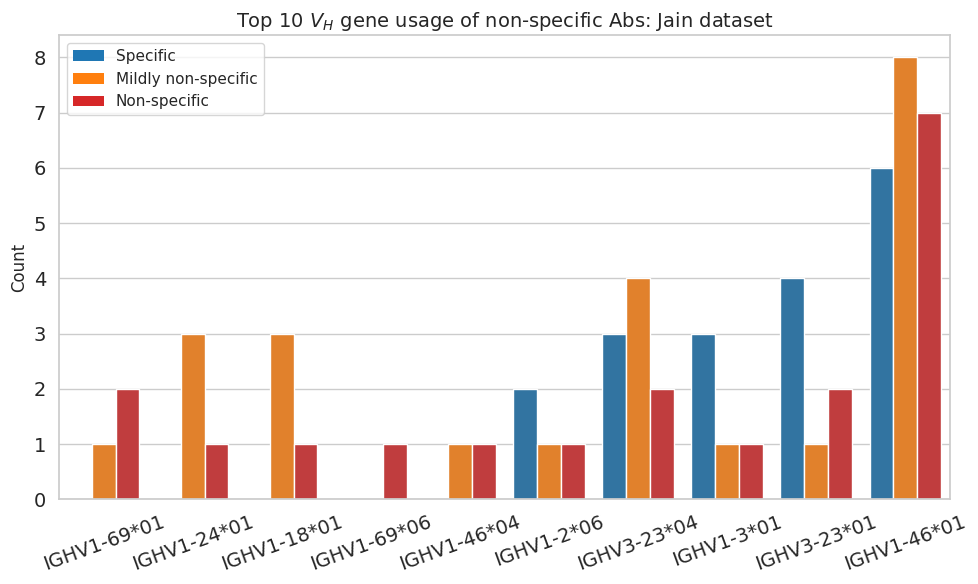

In [98]:
Jain_data = data_combined[data_combined['Dataset']=='Jain'].copy()
Jain_data['class'] = [0 if i == 0 else 0.5 if (i > 0 and i < 4) else 1 for i in Jain_data['react']]

counts_df = plot_top_vcalls_by_class_selected_by_class1(Jain_data, vcol='v_call VH', title='Jain dataset', classcol='class', top_n=10)
#counts_df = plot_top_vcalls_by_class_selected_by_class0(Jain_data, vcol='v_call VH', classcol='class', top_n=10)

/tmp/ipykernel_109946/1906849994.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=counts_top,


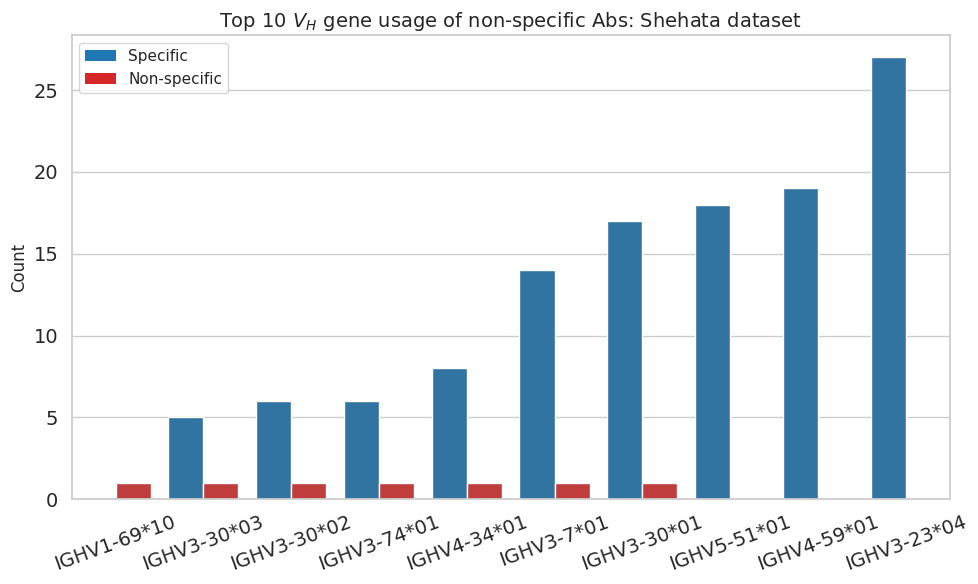

In [99]:
Shehata_data = data_combined[data_combined['Dataset']=='Shehata'].copy()
Shehata_data['class'] = [0 if i<=0.33 else 1 for i in list(Shehata_data['PSR Score'])]

counts_df = plot_top_vcalls_by_class_selected_by_class1(Shehata_data, vcol='v_call VH', title='Shehata dataset', classcol='class', top_n=10)